## Chapter 1: Introduction & Problem Context

**Problem framing (what is being predicted):**
- We treat AAPL daily market data as a supervised learning dataset.
- Input `X` consists of engineered features computed from day `t`.
- Output `y` is the **next-day Adjusted Close** on day `t+1` (`target_close_1d`).

**Why Adjusted Close:**
- Adjusted Close is commonly used in equity time series because it reflects corporate actions (e.g., splits/dividends) more consistently than raw close.

**How leakage is avoided:**
- All features are constructed from values at or before day `t`.
- The label is created by shifting the Adjusted Close series forward by one day.
- Rows containing `NaN` created by rolling indicators or the shifted target are removed only after feature/label creation.

**Where this notebook fits in the pipeline:**
- This notebook prepares and saves the processed dataset and a single source-of-truth feature config.
- Subsequent notebooks consume these artifacts for time-aware splitting, model training, and evaluation.



In [102]:
import numpy as np
import pandas as pd
import pandas_ta as ta
import yfinance as yf
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", 200)


In [103]:
TICKER = "AAPL"
PERIOD = "10y"
INTERVAL = "1d"
ALPHA = 0.2

# Candidate features available for modeling (centralized here)
FEATURES = [
    "rsi_14",
    "macd_hist_12_26_9",
    "bb_bandwidth_20_2",
    "adx_14",
    "obv",
    "adj_close_smooth",
    "ema_20",
    "atr_14",
    "volume"
    # "target_ret_1d_pct"
]
    
TARGET = "target_close_1d"


In [104]:
OUT_DIR = Path("../data/processed")
OUT_DIR.mkdir(parents=True, exist_ok=True)

# Shared dataset path consumed by Notebook 02 and Notebook 03
FEATURE_PATH_CSV = OUT_DIR / "aapl_features_smoothed.csv"

# Single source-of-truth modeling config for downstream notebooks
MODEL_CONFIG_PATH = OUT_DIR / "modeling_config.json"

## Chapter 2: Dataset & Preprocessing

### Dataset Description
- **Source:** Yahoo Finance via `yfinance`.
- **Asset:** `AAPL` (Apple Inc.).
- **Sampling:** daily bars (`interval = 1d`) over the last ~5 years (`period = 5y`).
- **Raw fields used:** `High`, `Low`, `Close`, `Adj Close`, `Volume` (time indexed by trading date).

In [105]:
df = yf.download(
    TICKER,
    period=PERIOD,
    interval=INTERVAL,
    auto_adjust=False,
    actions=False,
    progress=False,
)
df

Price,Adj Close,Close,High,Low,Open,Volume
Ticker,AAPL,AAPL,AAPL,AAPL,AAPL,AAPL
Date,,,,,,
2016-04-13,25.374878,28.010000,28.084999,27.700001,27.700001,133029200
2016-04-14,25.388462,28.025000,28.097500,27.832500,27.905001,101895600
2016-04-15,24.878881,27.462500,28.075001,27.432501,28.027500,187756000
2016-04-18,24.342119,26.870001,27.237499,26.735001,27.222500,243286000
2016-04-19,24.213020,26.727501,27.000000,26.557501,26.969999,129539600
...,...,...,...,...,...,...
2026-04-07,253.500000,253.500000,256.200012,245.699997,256.160004,62148000
2026-04-08,258.899994,258.899994,259.750000,256.529999,258.450012,41032800


### Prepare Clean 1D Series and Apply Smoothing

This section standardizes the OHLCV inputs into clean 1D numeric series, then applies exponential smoothing to reduce noise before feature engineering.

**Justification**: Exponential smoothing emphasizes recent observations while still retaining historical context, producing more stable indicator inputs and helping reduce sensitivity to one-day, abnormal spikes.

In [106]:
def to_series_1d(x, name: str) -> pd.Series:
    """Coerce 1-col DataFrame/Series into a clean numeric Series."""
    if isinstance(x, pd.DataFrame):
        if x.shape[1] != 1:
            raise ValueError(f"Expected 1 column for {name}, got {x.shape[1]}")
        x = x.iloc[:, 0]
    s = pd.Series(x, index=x.index, name=name)
    return pd.to_numeric(s, errors="coerce")


def exp_smooth(series: pd.Series, alpha: float = 0.2) -> pd.Series:
    return series.ewm(alpha=alpha, adjust=False).mean()


raw_close = to_series_1d(df["Close"], "Close")
raw_adj_close = to_series_1d(df["Adj Close"], "Adj Close")
raw_high = to_series_1d(df["High"], "High")
raw_low = to_series_1d(df["Low"], "Low")
raw_volume = to_series_1d(df["Volume"], "Volume")

s_adj_close = exp_smooth(raw_adj_close, ALPHA)
s_high = exp_smooth(raw_high, ALPHA)
s_low = exp_smooth(raw_low, ALPHA)
s_volume = exp_smooth(raw_volume, ALPHA)

#### Compare Raw vs Smoothed Price

This section visualizes the original close price against the smoothed adjusted close series to show how smoothing reduces short-term noise while preserving the broader trend.

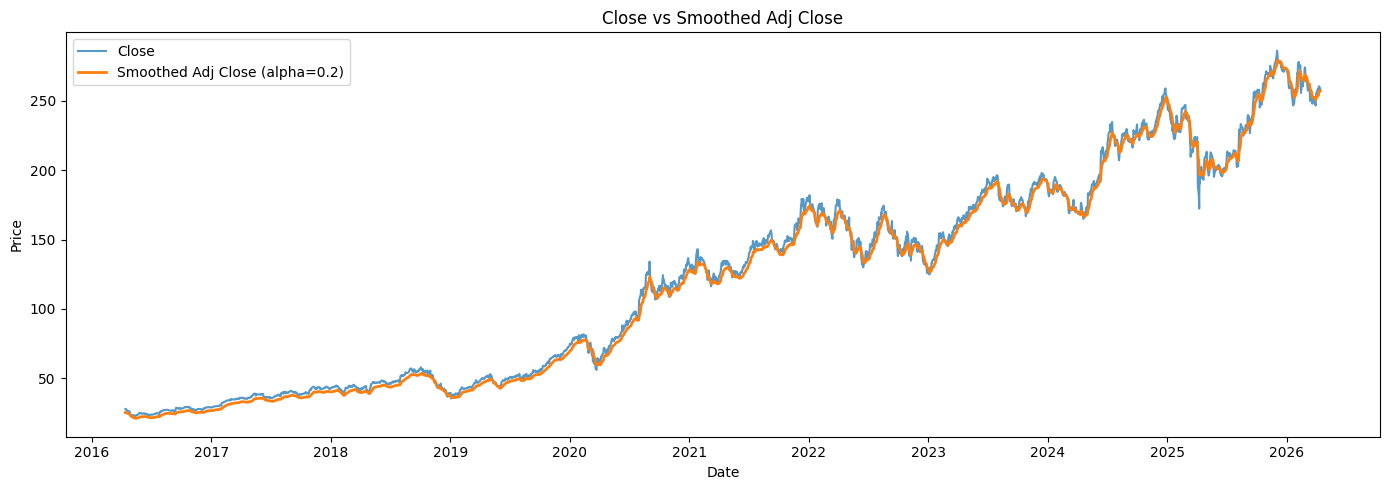

In [107]:
fig, ax = plt.subplots(figsize=(14, 5))

ax.plot(raw_close.index, raw_close, label="Close", alpha=0.75)
ax.plot(s_adj_close.index, s_adj_close, label=f"Smoothed Adj Close (alpha={ALPHA})", linewidth=2)

ax.set_title("Close vs Smoothed Adj Close")
ax.set_xlabel("Date")
ax.set_ylabel("Price")
ax.legend()
plt.tight_layout()
plt.show()


### Technical Indicator Overview

Before computing indicators such as `ta.rsi`, `ta.macd`, and `ta.adx`, it helps to group them by category and purpose:

| Category | Example Indicators | What They Capture | Why Included |
|---|---|---|---|
| Momentum | RSI, MACD | Speed and direction of recent price movement | Helps detect overextension and short-term reversals |
| Trend | SMA, EMA, ADX | Direction and strength of ongoing trend | Helps model persistent up/down market regimes |
| Volatility | Bollinger Bands, ATR | Magnitude of price fluctuation | Helps represent market risk and changing uncertainty |
| Volume-based | OBV | Buying/selling pressure behind moves | Adds participation context that price alone may miss |

These indicators convert raw OHLCV into structured market-state signals, giving feature selection a broader and more complementary candidate set for more robust labeling/smoothing outcomes.

In [108]:
feat = pd.DataFrame(index=df.index)

# Keep core price references (ensure 1D numeric series)
feat["Adj Close"] = raw_adj_close
feat["adj_close_smooth"] = s_adj_close
feat["target_ret_1d_pct"] = (raw_adj_close.pct_change().shift(-1) * 100)

feat["volume"] = s_volume

# Indicator engineering
feat["rsi_14"] = ta.rsi(s_adj_close, length=14)

macd_df = ta.macd(close=s_adj_close, fast=12, slow=26, signal=9)
feat["macd_hist_12_26_9"] = macd_df["MACDh_12_26_9"]

adx_df = ta.adx(high=s_high, low=s_low, close=s_adj_close, length=14)
feat["adx_14"] = adx_df["ADX_14"]

feat["atr_14"] = ta.atr(high=s_high, low=s_low, close=s_adj_close, length=14)
feat["obv"] = ta.obv(close=s_adj_close, volume=s_volume)
feat["sma_10"] = ta.sma(s_adj_close, length=10)
feat["ema_20"] = ta.ema(s_adj_close, length=20)

bb_df = ta.bbands(s_adj_close, length=20, std=2)
feat["bb_bandwidth_20_2"] = bb_df["BBB_20_2"]

# Targets available for training
feat["target_close_1d"] = raw_adj_close.shift(-1)

### Missing-Value Row Removal (`dropna`)

This section removes any rows in that still contain missing (`NaN`) values to ensure a clean dataset for modeling.

In [109]:
rows_before = len(feat)
feat = feat.dropna().copy()
rows_after = len(feat)

summary = pd.DataFrame({
    "metric": ["rows_before_dropna", "rows_after_dropna", "rows_removed"],
    "value": [rows_before, rows_after, rows_before - rows_after],
})

print("Final modeling shape:", feat.shape)
display(summary)

missing_tbl = pd.DataFrame({
    "missing_count": feat.isna().sum(),
}).sort_values("missing_count", ascending=False)
missing_tbl

Final modeling shape: (2480, 13)


,metric,value
0,rows_before_dropna,2514
1,rows_after_dropna,2480
2,rows_removed,34


,missing_count
Adj Close,0
adj_close_smooth,0
target_ret_1d_pct,0
volume,0
rsi_14,0
macd_hist_12_26_9,0
adx_14,0
atr_14,0
obv,0
sma_10,0


### Save Processed Outputs

This section saves the cleaned feature dataset and writes a modeling configuration file so the same inputs can be reused consistently in later training and evaluation steps.

In [110]:
import json

saved_to = []

feat.to_csv(FEATURE_PATH_CSV, index=True)
saved_to.append(str(FEATURE_PATH_CSV))

model_config = {
    "data_csv": str(FEATURE_PATH_CSV),
    "feature_cols": FEATURES,
    "target_col": TARGET,
}

MODEL_CONFIG_PATH.write_text(json.dumps(model_config, indent=2), encoding="utf-8")

print("Saved processed feature dataset to:")
for path in saved_to:
    print("-", path)

print("Saved modeling config to:")
print("-", MODEL_CONFIG_PATH)

feat.head()


Saved processed feature dataset to:
- ..\data\processed\aapl_features_smoothed.csv
Saved modeling config to:
- ..\data\processed\modeling_config.json


,Adj Close,adj_close_smooth,target_ret_1d_pct,volume,rsi_14,macd_hist_12_26_9,adx_14,atr_14,obv,sma_10,ema_20,bb_bandwidth_20_2,target_close_1d
Date,,,,,,,,,,,,,
2016-05-31,22.754038,22.340601,-1.401967,1.670290e+08,49.327530,0.364617,75.439719,2.375693,-1.812087e+09,21.699815,22.196014,7.108358,22.435034
2016-06-01,22.435034,22.359487,-0.751555,1.569618e+08,49.876780,0.358149,70.590680,2.372857,-1.655125e+09,21.812270,22.211583,7.094068,22.266422
2016-06-02,22.266422,22.340874,0.204634,1.577228e+08,49.309527,0.342375,66.200984,2.365781,-1.812848e+09,21.916635,22.223897,7.327383,22.311987
2016-06-03,22.311987,22.335097,0.725087,1.489821e+08,49.122774,0.321636,62.124837,2.359600,-1.961830e+09,22.017079,22.234487,7.684564,22.473768
2016-06-06,22.473768,22.362831,0.405594,1.378197e+08,50.099791,0.300276,57.830825,2.366450,-1.824010e+09,22.112974,22.246710,8.098510,22.564920
